# VGG Network

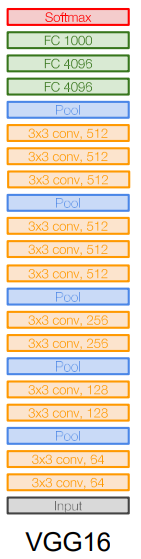

In [ ]:
# FROM THE PAPER:
# input = fixed size 224x224 RGB images
# conv stride=1
# padding --> to preserve spatial resolution after conv --> padding=1 for 3x3 conv
# Max Pooling --> 2x2, stride=2 --> SPATIAL RESOLUTION DIVIDED BY 2!

# VGG16 has 16 weight layers

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import pandas as pd
import numpy as np

In [24]:
# ARCHITECTURE
VGG16ARC = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

# flatten -> FC 4096 -> FC 4096 -> FC 1000 -> softmax

In [25]:
class VGG16(nn.Module):
    def __init__(self, in_channels=3, num_classes=1000):
        
        super(VGG16, self).__init__()
        self.in_channels = in_channels
        self.conv_layers = self.create_conv_layers(VGG16ARC)
        
        #fully-connected layers: 
        #   1) 512 channels * 7x7 images (224 divided by 5 max-pools stride=2) neurons
        #   2) 4096 neurons
        #   3) ReLU + Dropout
        self.fc = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        
        # reshaping (flatten it to the linear part)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)
        
        return x
    
    def create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels
        
        for x in architecture:
            if type(x) == int:
                out_channels = x
                
                layers += [nn.Conv2d(
                    in_channels=in_channels, 
                    out_channels=out_channels, 
                    kernel_size=3, 
                    stride=1, 
                    padding=1), 
                           nn.ReLU()]
                
                in_channels = x     
            elif x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
                
        # unpacking layers list to create sequential layers (so, the network)     
        return nn.Sequential(*layers)
                
                
        

In [ ]:
# NO TRAINING, NO SOFTMAX, CASUAL WEIGHTS!!!
model = VGG16(3, 1000)
x = torch.randn(1, 3, 224, 224)

# vettore di 1000 classi
print(model(x).shape) 

torch.Size([1, 1000])


#### MNIST Training

In [ ]:
import torchvision.transforms as transforms

#   1) conversione input in immagine PIL
#   2) ridimensionamento: 28x28 --> 224x224 (adatta mnist alla VGG)
#   3) conversione PIL --> tensore [1, 224, 224]

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
# Creazione dataset compatibile con pytorch da file CSV

class MNISTDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        data = pd.read_csv(csv_file)
        
        # pixels
        self.X = data.iloc[:, 1:].values
        # labels
        self.y = data.iloc[:, 0].values
        
        # normalization [0, 255] --> [0, 1]
        self.X = self.X / 255.0
        
        # from pandas to pytorch
        self.transform = transform
        
    # DUNDER METHOD
    def __len__(self):
        # number of examples in dataset
        return len(self.X)
    
    # DUNDER METHOD
    def __getitem__(self, index):
        x = self.X[index]
        y = self.y[index]
        
        x = torch.tensor(x, dtype=torch.float32)
        
        x = x.reshape(28, 28)
        
        if self.transform:
            x = self.transform(x)
        
        # label conversion for cross-entropy loss
        y = torch.tensor(y, dtype=torch.long)
        
        # ritorna il tensore (immagine) e la label
        return x, y
    
train_dataset = MNISTDataset("mnist_train.csv", transform=transform)
test_dataset = MNISTDataset("mnist_test.csv", transform=transform)

# DataLoader calls dunder methods automatically (*)
# DataLoader divides the dataset in batch of 64 images, shuffling the data
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# i DUNDER METHODS sono metodi chiamati automaticamente da PyTorch (*)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VGG16(in_channels=1, num_classes=10).to(device)

# loss: softmax + negative log likelihood from logits
criterion = nn.CrossEntropyLoss()

# updates model weights with gradients and momentums
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training

epochs = 5

# each "epoch" is a complete passage on the training datasets
for epoch in range(epochs):
    
    # it activates dropout and batchnorm
    model.train()
    
    # here previous dunder methods are used (*)
    # it takes previous batch (64 images) from the data loader
    for images, labels in train_loader:
        
        # moves data to device (gpu or cpu)
        images, labels = images.to(device), labels.to(device)
        
        # forward pass
        outputs = model(images)
        
        # calculates loss
        loss = criterion(outputs, labels)
        
        # avoids gradients accumulation
        optimizer.zero_grad()
        
        # performs loss in pytorch graph
        loss.backward()
        
        # updates CNN kernels and fully-connected layers' weights
        optimizer.step()
    
    # Print final error on the epoch
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

In [ ]:
# Testing 

# no dropout, fixed-batchnorm
model.eval()
correct = 0
total = 0

# disables gradients (faster, less memory)
with torch.no_grad():
    
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # forward test
        outputs = model(images)
        
        # it takes the maximum logit index
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        
        # counts correct predictions
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")